## 1. Import Required Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset


In [2]:
file_path = "Food_Delivery_Visualization_Dataset csv"

df = pd.read_csv(file_path)

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (360, 16)


,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


## 3. Understand the Dataset



In [3]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNumerical summary:")
display(df.describe().round(2))

Rows and columns: (360, 16)

Column names:
['Order_Batch_ID', 'Date', 'Month', 'Day', 'City', 'Cuisine', 'Order_Channel', 'Weather', 'Orders', 'Average_Order_Value', 'Revenue', 'Marketing_Spend', 'Discounts', 'Avg_Delivery_Minutes', 'Customer_Rating', 'Repeat_Customer_Percent']

Data types:


,Data Type
Order_Batch_ID,object
Date,datetime64[ns]
Month,object
Day,object
City,object
Cuisine,object
Order_Channel,object
Weather,object
Orders,int64
Average_Order_Value,float64



Missing values:


,Missing Values
Order_Batch_ID,0
Date,0
Month,0
Day,0
City,0
Cuisine,0
Order_Channel,0
Weather,0
Orders,0
Average_Order_Value,0



Duplicate rows: 0

Numerical summary:


,Date,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
count,360,360.00,360.00,360.00,360.00,360.00,360.00,360.00,360.00
mean,2025-06-30 21:31:59.999999744,147.65,409.15,60591.11,27161.43,5753.40,32.58,4.45,41.60
min,2025-01-02 00:00:00,58.00,243.76,20618.53,11336.64,1219.31,20.60,3.81,24.80
25%,2025-04-05 12:00:00,123.75,353.84,48400.83,21822.50,3566.62,28.68,4.31,37.90
50%,2025-06-26 12:00:00,147.00,412.41,58779.19,25874.14,5226.87,32.00,4.47,41.90
75%,2025-09-25 12:00:00,169.00,464.94,71740.14,32387.14,7610.37,35.95,4.61,45.22
max,2025-12-28 00:00:00,235.00,575.94,121381.98,45000.00,15000.00,50.10,4.94,54.00
std,NaN,33.39,70.25,17387.93,6970.56,2647.41,5.28,0.21,5.34


In [4]:
categorical_cols = ["City", "Cuisine", "Order_Channel", "Weather"]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())

print("\nDate range:", df["Date"].min().date(), "to", df["Date"].max().date())


City:
['Hyderabad' 'Chandigarh' 'Mumbai' 'Pune' 'Bengaluru' 'Delhi' 'Kochi'
 'Jaipur']

Cuisine:
['North Indian' 'Chinese' 'Healthy' 'Fast Food' 'South Indian' 'Biryani']

Order_Channel:
['App' 'Partner Platform' 'Website']

Weather:
['Hot' 'Rainy' 'Clear' 'Cloudy']

Date range: 2025-01-02 to 2025-12-28


### Data Quality Interpretation


## 4. Feature Engineering for Time Analysis



In [5]:
df["Month_Period"] = df["Date"].dt.to_period("M")
df["Month_Name"] = df["Date"].dt.strftime("%b")

monthly = (
    df.groupby("Month_Period", as_index=False)
      .agg(
          Orders=("Orders", "sum"),
          Revenue=("Revenue", "sum"),
          Marketing_Spend=("Marketing_Spend", "sum")
      )
)

monthly["Month"] = monthly["Month_Period"].astype(str)
monthly

,Month_Period,Orders,Revenue,Marketing_Spend,Month
0,2025-01,3318,1307391.72,474713.66,2025-01
1,2025-02,2853,1129272.69,441326.53,2025-02
2,2025-03,5073,2143752.84,1112321.33,2025-03
3,2025-04,5343,2177469.56,799644.18,2025-04
4,2025-05,3433,1395617.16,498169.79,2025-05
5,2025-06,5816,2366928.56,1396331.66,2025-06
6,2025-07,4107,1737726.54,676325.29,2025-07
7,2025-08,4951,1877308.87,782748.85,2025-08
8,2025-09,3782,1515392.97,890372.32,2025-09
9,2025-10,4534,1811552.37,726173.09,2025-10


## 5. Line Plot — Orders and Revenue Over Time


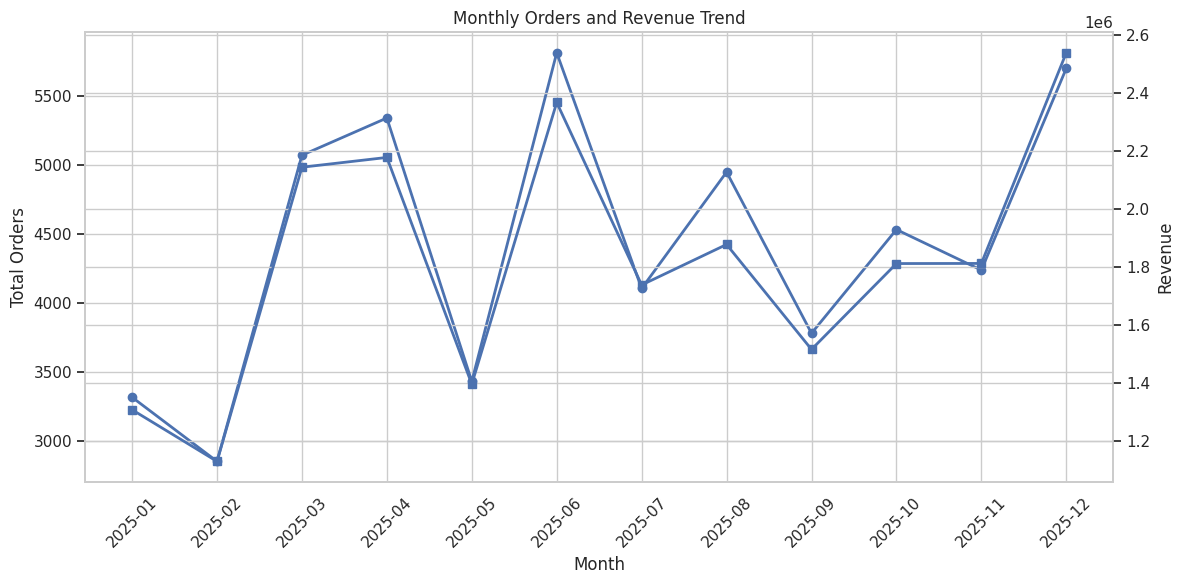

In [6]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(monthly["Month"], monthly["Orders"], marker="o", linewidth=2, label="Orders")
ax1.set_xlabel("Month")
ax1.set_ylabel("Total Orders")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly["Month"], monthly["Revenue"], marker="s", linewidth=2, label="Revenue")
ax2.set_ylabel("Revenue")

plt.title("Monthly Orders and Revenue Trend")
fig.tight_layout()
plt.show()

### Interpretation

Orders and revenue fluctuate considerably across the year rather than following a perfectly steady upward trend. **June records the highest order volume (5,816 orders)**, while **December records the highest monthly revenue (about ₹2.54 crore)**. January and February are comparatively weaker months. The difference between the peak order month and peak revenue month suggests that revenue is influenced not only by order volume but also by order value and the mix of orders.

## 6. Bar Chart — City-wise Business Performance


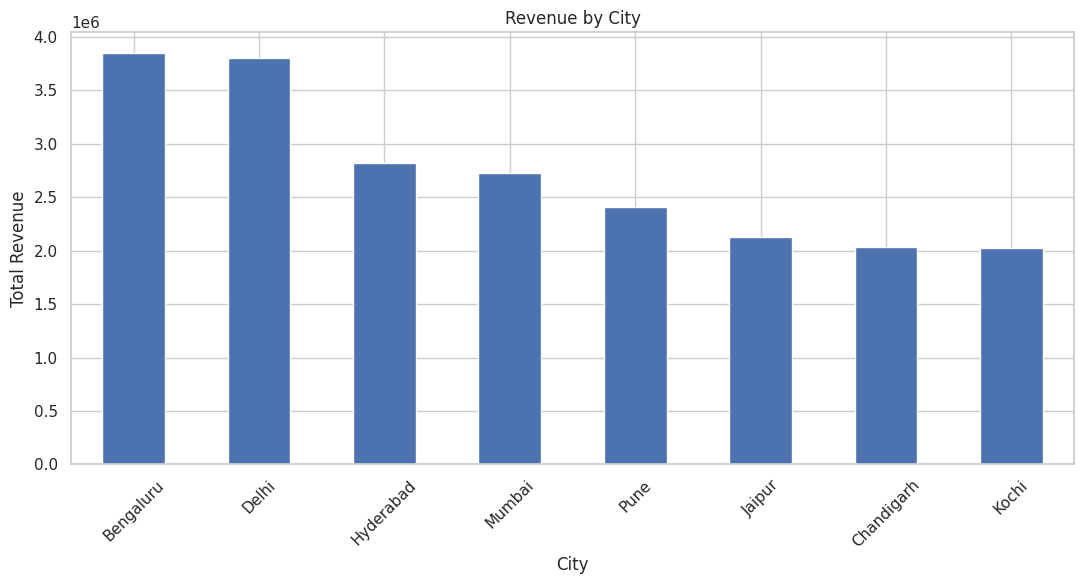

,Orders,Revenue
City,,
Bengaluru,9394,3851958.65
Delhi,9288,3808183.88
Hyderabad,7140,2824382.94
Mumbai,6633,2730403.79
Pune,5812,2406273.63
Jaipur,4931,2129246.70
Chandigarh,5002,2034416.22
Kochi,4953,2027935.51


In [7]:
city_summary = (
    df.groupby("City")
      .agg(
          Orders=("Orders", "sum"),
          Revenue=("Revenue", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

fig, ax1 = plt.subplots(figsize=(11, 6))
city_summary["Revenue"].plot(kind="bar", ax=ax1)
ax1.set_title("Revenue by City")
ax1.set_xlabel("City")
ax1.set_ylabel("Total Revenue")
ax1.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

display(city_summary)

### Interpretation

**Bengaluru** generates the highest total revenue (about ₹38.52 lakh), closely followed by **Delhi** (about ₹38.08 lakh). Bengaluru also has the highest total order count. **Kochi and Chandigarh** are among the lower-revenue cities in this dataset. This indicates that city-level demand is uneven and that high-order-volume markets deserve continued operational and marketing attention.

## 7. Bar Chart — Cuisine Performance



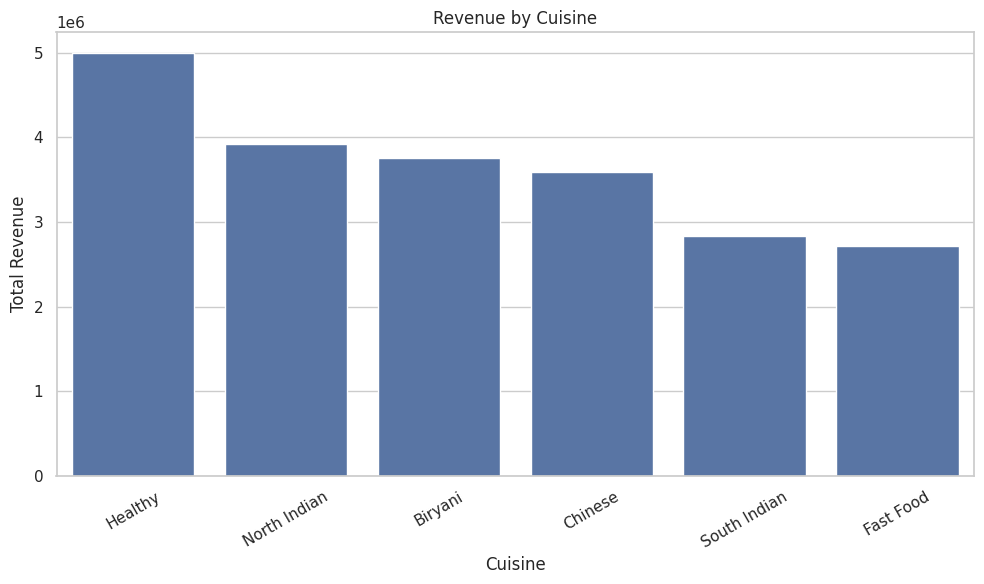

,Orders,Revenue,Average_Order_Value
Cuisine,,,
Healthy,10024,4988656.66,501.84
North Indian,9030,3915404.79,428.87
Biryani,8141,3760155.52,458.85
Chinese,9167,3594364.34,386.09
South Indian,8189,2838647.33,344.85
Fast Food,8602,2715572.68,316.67


In [8]:
cuisine_summary = (
    df.groupby("Cuisine")
      .agg(
          Orders=("Orders", "sum"),
          Revenue=("Revenue", "sum"),
          Average_Order_Value=("Average_Order_Value", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=cuisine_summary.reset_index(),
    x="Cuisine",
    y="Revenue"
)
plt.title("Revenue by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

display(cuisine_summary.round(2))

### Interpretation

**Healthy cuisine** is the strongest revenue contributor, generating about ₹49.89 lakh, and it also has the highest average order value (about ₹501.84). North Indian and Biryani are the next strongest revenue categories. **Fast Food** has the lowest revenue and the lowest average order value in this dataset. Therefore, cuisine performance is driven by both order volume and the value of individual orders.

## 8. Scatter Plot — Marketing Spend vs Revenue



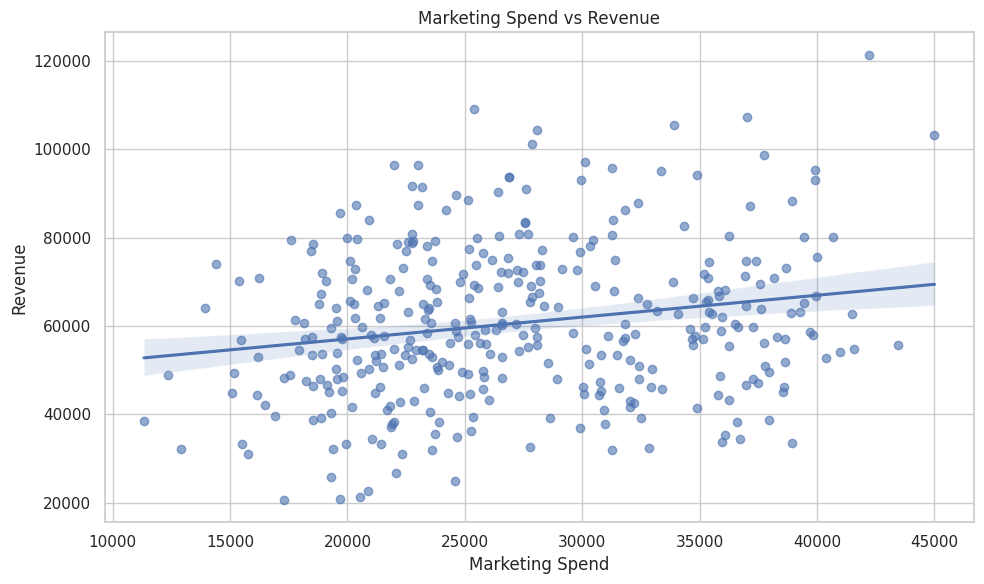

Pearson correlation: 0.198


In [9]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x="Marketing_Spend",
    y="Revenue",
    scatter_kws={"alpha": 0.6},
    line_kws={}
)
plt.title("Marketing Spend vs Revenue")
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

marketing_corr = df["Marketing_Spend"].corr(df["Revenue"])
print(f"Pearson correlation: {marketing_corr:.3f}")

### Interpretation

Marketing spend and revenue show a **weak positive linear relationship** in the raw records, with Pearson correlation of approximately **0.198**. This means higher marketing spend is sometimes associated with higher revenue, but the relationship is not strong. Other factors such as orders, average order value, city, cuisine, weather and channel likely contribute substantially to revenue.

## 9. Scatter Plot — Delivery Time vs Customer Rating



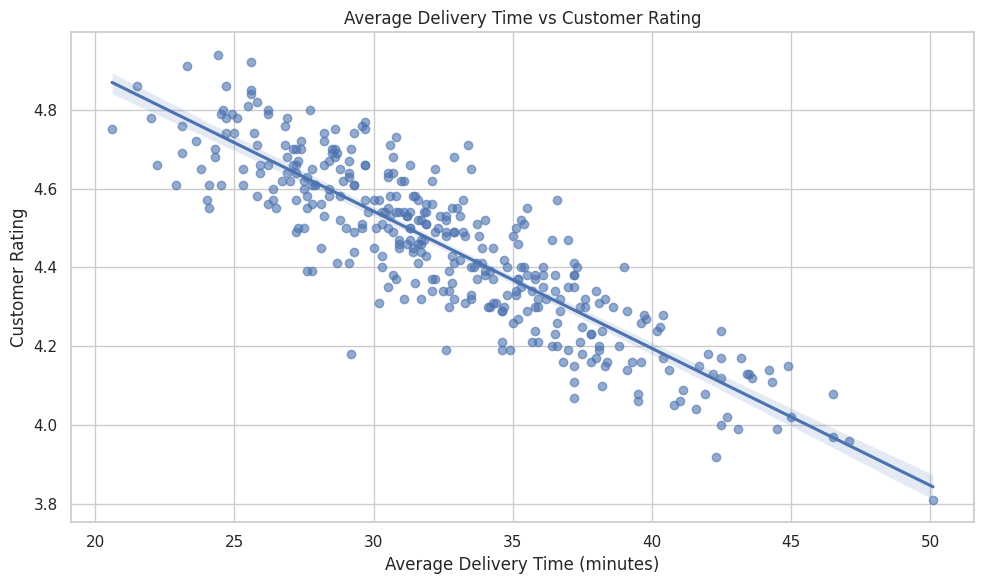

Pearson correlation: -0.876


In [10]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x="Avg_Delivery_Minutes",
    y="Customer_Rating",
    scatter_kws={"alpha": 0.6},
    line_kws={}
)
plt.title("Average Delivery Time vs Customer Rating")
plt.xlabel("Average Delivery Time (minutes)")
plt.ylabel("Customer Rating")
plt.tight_layout()
plt.show()

delivery_rating_corr = df["Avg_Delivery_Minutes"].corr(df["Customer_Rating"])
print(f"Pearson correlation: {delivery_rating_corr:.3f}")

### Interpretation

There is a **strong negative relationship** between delivery time and customer rating, with Pearson correlation of approximately **-0.876**. In this dataset, longer delivery times are strongly associated with lower ratings. This makes delivery efficiency an important operational factor for customer satisfaction. The relationship is observational, so it should not be interpreted as proof of causation by itself.

## 10. Histogram — Distribution of Orders

A histogram shows how frequently different ranges of order volumes occur. It helps identify the typical order range and whether the data contains unusually high or low observations.

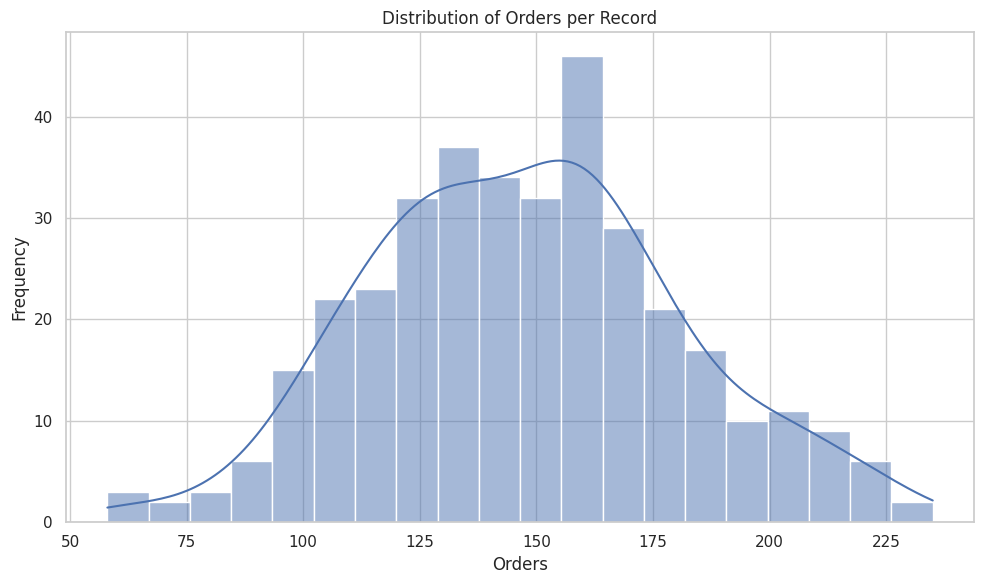

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="Orders", bins=20, kde=True)
plt.title("Distribution of Orders per Record")
plt.xlabel("Orders")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Interpretation

The histogram shows that order volumes vary across records, with most observations concentrated around the middle of the observed range and fewer records at the extremes. This confirms that the business experiences meaningful variation in order demand rather than a constant daily/periodic volume.

## 11. Box Plot — Delivery Time by Weather



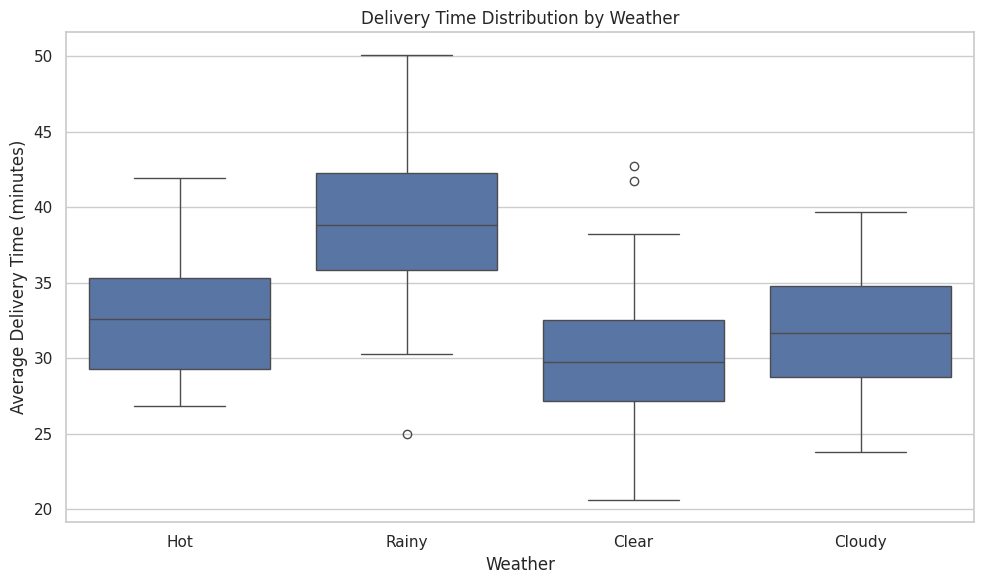

,Orders,Revenue,Avg_Delivery_Minutes,Customer_Rating
Weather,,,,
Clear,21564,8994356.98,29.99,4.53
Cloudy,13628,5633965.72,31.72,4.50
Rainy,11108,4512017.74,38.75,4.23
Hot,6853,2672460.88,32.47,4.47


In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Weather", y="Avg_Delivery_Minutes")
plt.title("Delivery Time Distribution by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Delivery Time (minutes)")
plt.tight_layout()
plt.show()

weather_summary = (
    df.groupby("Weather")
      .agg(
          Orders=("Orders", "sum"),
          Revenue=("Revenue", "sum"),
          Avg_Delivery_Minutes=("Avg_Delivery_Minutes", "mean"),
          Customer_Rating=("Customer_Rating", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

display(weather_summary.round(2))

### Interpretation

**Rainy weather has the highest average delivery time (about 38.75 minutes)** and the lowest average customer rating (about 4.23). Clear weather has the fastest average delivery time (about 30.00 minutes) and the highest rating (about 4.53). This indicates that weather conditions, particularly rain, are associated with delivery delays and weaker customer satisfaction. Clear weather also has the highest total orders and revenue in the dataset.

## 12. Violin Plot — Customer Ratings by Order Channel



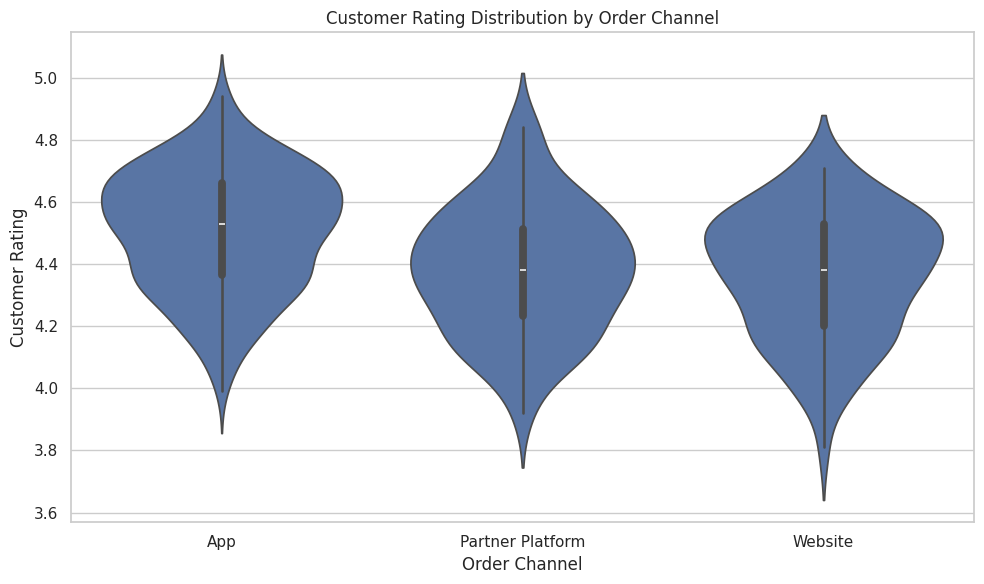

,Orders,Revenue,Customer_Rating
Order_Channel,,,
App,32335,13435579.94,4.51
Website,10803,4471108.12,4.37
Partner Platform,10015,3906113.26,4.38


In [13]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="Order_Channel", y="Customer_Rating", inner="box")
plt.title("Customer Rating Distribution by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Customer Rating")
plt.tight_layout()
plt.show()

channel_summary = (
    df.groupby("Order_Channel")
      .agg(
          Orders=("Orders", "sum"),
          Revenue=("Revenue", "sum"),
          Customer_Rating=("Customer_Rating", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

display(channel_summary.round(2))

### Interpretation

The **App** is the strongest order channel, with **32,335 orders and about ₹1.34 crore in revenue**, far ahead of the Website and Partner Platform. It also has the highest average customer rating (about 4.51). The channel results suggest that the app is currently the most important digital ordering route in this dataset.

## 13. Count Plot — Number of Records by Weather



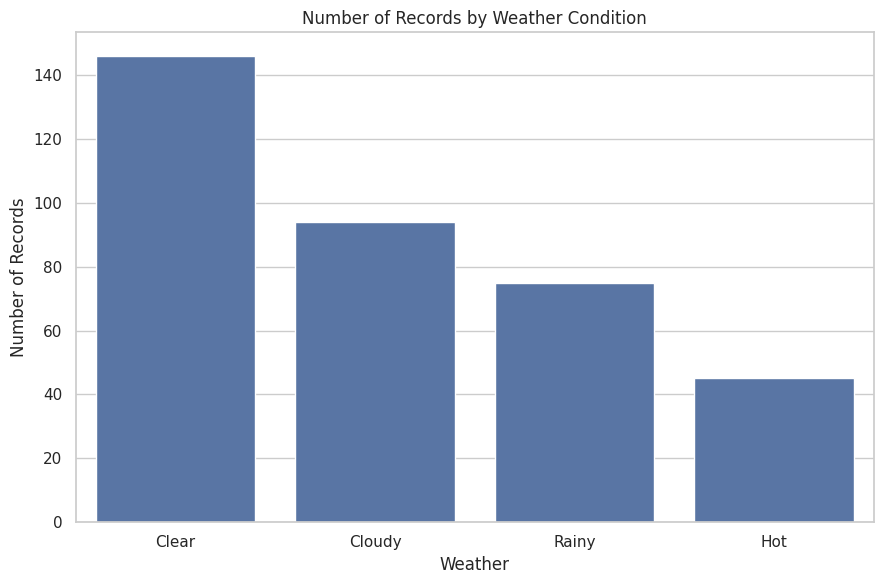

In [14]:
plt.figure(figsize=(9, 6))
sns.countplot(data=df, x="Weather", order=df["Weather"].value_counts().index)
plt.title("Number of Records by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

### Interpretation

The count plot shows that **Clear weather is the most frequently represented condition**, while Hot weather has fewer records. Because this is a frequency-of-records chart, it should be interpreted together with the aggregated order and revenue results rather than assuming that weather frequency alone determines business performance.

## 14. Count Plot — Order Channel


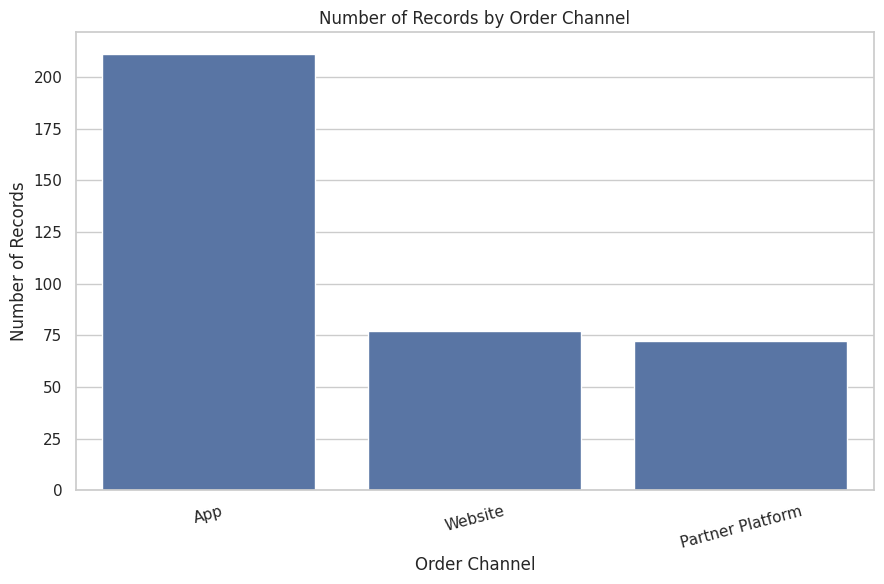

In [15]:
plt.figure(figsize=(9, 6))
sns.countplot(data=df, x="Order_Channel", order=df["Order_Channel"].value_counts().index)
plt.title("Number of Records by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Number of Records")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Interpretation

The App has the largest number of records among the three channels. This supports the aggregate result that the App is a major contributor to the business. However, total orders and revenue should remain the primary measures for business performance because record count alone does not indicate the number or value of orders.

## 15. Correlation Heatmap — Numerical Business Variables



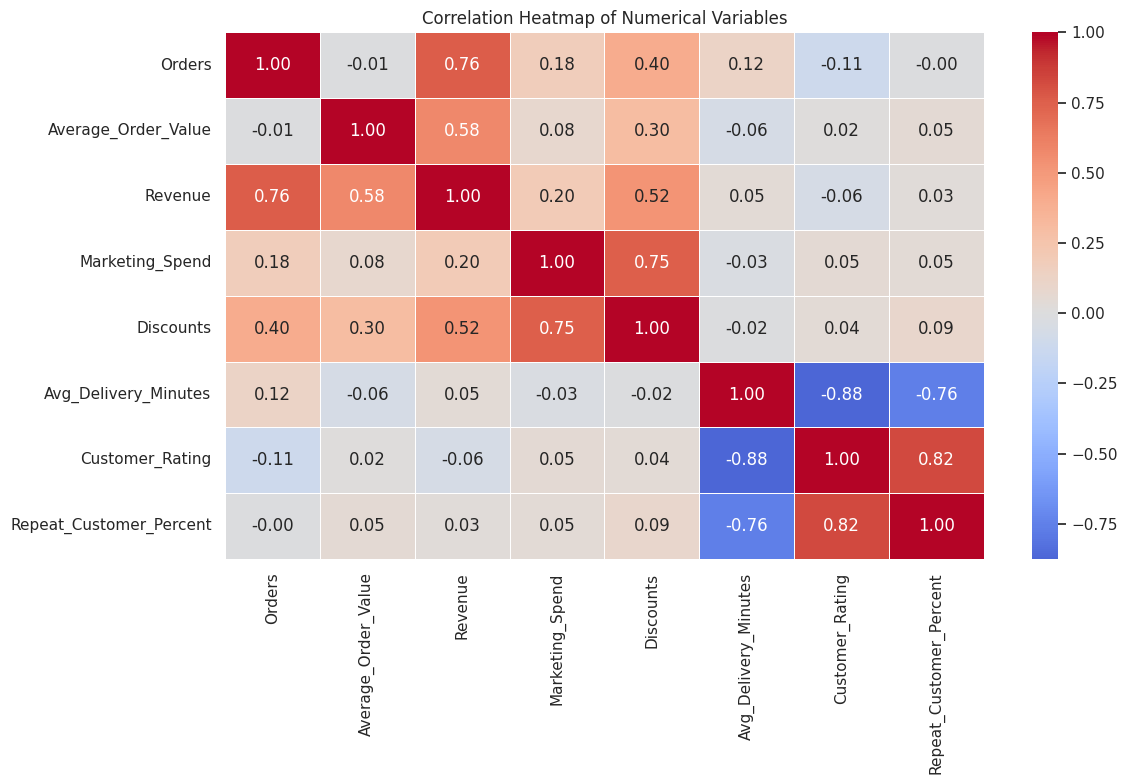

In [16]:
numeric_cols = [
    "Orders",
    "Average_Order_Value",
    "Revenue",
    "Marketing_Spend",
    "Discounts",
    "Avg_Delivery_Minutes",
    "Customer_Rating",
    "Repeat_Customer_Percent"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

### Interpretation

The heatmap highlights several important relationships:

- **Orders and Revenue** have a strong positive correlation (about **0.76**), which is expected because more orders generally generate more revenue.
- **Delivery Time and Customer Rating** have a strong negative correlation (about **-0.88**), reinforcing the delivery-time analysis.
- **Customer Rating and Repeat Customer Percentage** show a strong positive relationship (about **0.82**), suggesting that better customer experiences are associated with greater repeat-customer levels.
- **Marketing Spend and Revenue** have only a weak positive correlation (about **0.20**) in the raw dataset.
- Discounts show a moderate positive association with orders (about **0.40**).

These are statistical associations and should not automatically be interpreted as causal relationships.

## 16. Additional Business KPI Summary



In [17]:
total_orders = df["Orders"].sum()
total_revenue = df["Revenue"].sum()
avg_order_value = df["Average_Order_Value"].mean()
avg_delivery = df["Avg_Delivery_Minutes"].mean()
avg_rating = df["Customer_Rating"].mean()
avg_repeat = df["Repeat_Customer_Percent"].mean()

kpi = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Total Revenue",
        "Average Order Value",
        "Average Delivery Time",
        "Average Customer Rating",
        "Average Repeat Customer %"
    ],
    "Value": [
        total_orders,
        total_revenue,
        avg_order_value,
        avg_delivery,
        avg_rating,
        avg_repeat
    ]
})

kpi.round(2)

,Metric,Value
0,Total Orders,53153.00
1,Total Revenue,21812801.32
2,Average Order Value,409.15
3,Average Delivery Time,32.58
4,Average Customer Rating,4.45
5,Average Repeat Customer %,41.60


## 17. Final Findings and Conclusion

### Most important findings

1. **Revenue and orders vary substantially across the year.** June has the highest total order volume, while December has the highest monthly revenue.
2. **Bengaluru is the leading city by revenue**, followed closely by Delhi. These cities are important high-volume markets.
3. **Healthy cuisine is the top revenue-generating cuisine** and also has the highest average order value.
4. **The App is the strongest order channel**, producing substantially more orders and revenue than the Website and Partner Platform.
5. **Rainy weather is associated with operational difficulty.** It has the longest average delivery time and the lowest customer rating.
6. **Delivery time and customer satisfaction are strongly negatively correlated** (approximately -0.88). Faster delivery is strongly associated with higher ratings in this dataset.
7. **Marketing spend has only a weak positive correlation with revenue** (approximately 0.20), so marketing investment alone does not explain revenue differences.
8. **Customer rating and repeat-customer percentage are strongly positively associated** (approximately 0.82), highlighting the importance of customer experience.
9. The correlation heatmap shows that **orders, revenue, delivery time, customer rating and repeat-customer percentage** are among the most informative relationships for business analysis.

### Overall conclusion

The visualization portfolio shows that food-delivery performance depends on a combination of **demand, order value, location, cuisine, ordering channel, weather and service quality**. The strongest operational insight is the relationship between delivery speed and customer satisfaction. The strongest commercial opportunities are concentrated in high-performing cities, the App channel and high-value cuisines such as Healthy food. Future analysis could investigate profitability, marketing ROI, seasonal campaigns and city-level operational improvements.